In [29]:
import numpy as np 
import pandas as pd  
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import product
import random
import importlib
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import sys
import os

# Add the 'code' folder directly to Python's search path
sys.path.append(os.path.join(os.getcwd(), 'src'))
from sklearn.datasets import make_moons
from sklearn.cluster import KMeans
from scipy.linalg import sqrtm


#import the synthetic data generation functions
import src.synthetic_data as syn_data
importlib.reload(syn_data)

#import the Wasserstein k-means clustering functions
import src.wasserstein as ws
importlib.reload(ws)

#import performance metrics functions for clustering evaluation 
import src.metrics as mt 
importlib.reload(mt)


#import trading alogrithms function for empirical performance 
import src.trading as tr
importlib.reload(tr)

import src.ledoit_wolf_sharpe_test as lw
importlib.reload(lw)

# Access to refinitiv data 
import refinitiv.data as rd

import src.equities_refinitiv as eq_ref
import src.macro_data as macro

# import FREDAPI 
from fredapi import Fred

#yahoo finance 
import yfinance as yf


import src.equity_loader as equity_loader

# (0) Initialise Data

In [30]:
start_date = '2006-01-01'
end_date = '2020-01-01'
interval = '1d'

In [31]:
df_america = equity_loader.get_close_prices(start_date=start_date, end_date=end_date, regions=['america'], interval=interval)

df_america.dropna(inplace=True)


# (1) Tuning Hysteresis (Entry/Exit Threshold)

## (1.1) Tuning for American Markets 

In [9]:
h2 = 1
h1 = 3
window_size = 20
N_S = 40
signal_type = "hysteresis"
_lookback = 10
S = df_america
L = 100
_initial_capital = 100
grad_weight = 0.5
_use_gradient = False
_live_plot = False

entry_threshold_list = [0.28, 0.29, 0.3]
hold_threshold_list  = [0.29, 0.3, 0.31]

# Store Sharpe ratios in a 2D array
sharpe_matrix = pd.DataFrame(index=entry_threshold_list, columns=hold_threshold_list, dtype=float)

for entry_threshold, hold_threshold in product(entry_threshold_list, hold_threshold_list):
    if entry_threshold >= hold_threshold:
        sharpe_matrix.loc[entry_threshold, hold_threshold] = np.nan
        continue

    print(f"Running entry={entry_threshold}, hold={hold_threshold}")

    portfolio_values, _, _, _  = tr.long_strat_implied(_initial_capital, N_S, S, L, h1, h2, window_size, start_date=start_date, end_date=end_date, signal_type=signal_type, entry_threshold=entry_threshold, hold_threshold=hold_threshold, lookback=_lookback, gradient_weight=grad_weight, use_gradient=_use_gradient, live_plot=_live_plot)

    # Compute Sharpe ratio from returns (adjust if your function returns something different)
    returns = np.diff(portfolio_values) / portfolio_values[:-1]
    if returns.std() > 0:
        sharpe = (returns.mean() / returns.std()) * np.sqrt(252 * 14)  # annualised for 14 years 
    else:
        sharpe = np.nan

    sharpe_matrix.loc[entry_threshold, hold_threshold] = sharpe



Running entry=0.28, hold=0.29
Running entry=0.28, hold=0.3
Running entry=0.28, hold=0.31
Running entry=0.29, hold=0.3
Running entry=0.29, hold=0.31
Running entry=0.3, hold=0.31


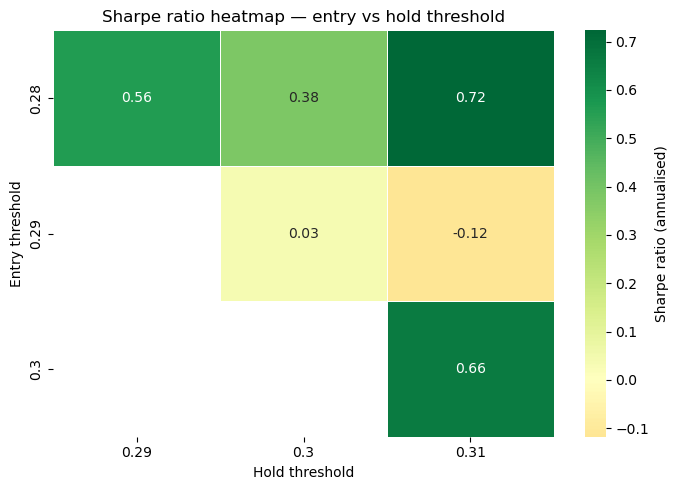

In [11]:
# Plot heatmap
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    sharpe_matrix.astype(float),
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    center=0,
    linewidths=0.5,
    ax=ax,
    cbar_kws={"label": "Sharpe ratio (annualised)"}
)
ax.set_title("Sharpe ratio heatmap — entry vs hold threshold")
ax.set_xlabel("Hold threshold")
ax.set_ylabel("Entry threshold")
plt.tight_layout()
plt.show()

# (2) Tuning Implied Sliced Wasserstein Probability trading strategy 

## (2.1) Find optimal Gradient weight $\alpha$ 

In [20]:
## Find the best tuning for the gradient weight for conviction signal
h1 = 3
h2 = 1
window_size = 20
N_S = 40
L = 100
_lookback = 10
_use_gradient = True
grad_weight_list = [0.0, 0.1,0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
S = df_america
_initial_capital = 100
#NOT USEFUL FOR NOW : 
entry_threshold = 0.28
hold_threshold = 0.31

results_conviction = {}
results_hysteresis = {}
results_continuous = {}
for grad_weight in grad_weight_list:
    print(f"Running grad_weight={grad_weight}")
    portfolio_value_conv, _, _, _  = tr.long_strat_implied(
        initial_capital   = _initial_capital,
        N_S               = N_S,
        S                 = S,
        L                 = L,
        h1                = h1,
        h2                = h2,
        window_size       = window_size,
        start_date        = start_date,
        end_date          = end_date,
        signal_type       = "conviction",
        entry_threshold   = entry_threshold,
        hold_threshold    = hold_threshold,
        gradient_weight       = grad_weight,
        lookback          = _lookback,
        use_gradient      = _use_gradient
    )
    portfolio_value_hyst, _, _, _  = tr.long_strat_implied(
        initial_capital   = _initial_capital,
        N_S               = N_S,
        S                 = S,
        L                 = L,
        h1                = h1,
        h2                = h2,
        window_size       = window_size,
        start_date        = start_date,
        end_date          = end_date,
        signal_type       = "hysteresis",
        entry_threshold   = entry_threshold,
        hold_threshold    = hold_threshold,
        gradient_weight       = grad_weight,
        lookback          = _lookback,
        use_gradient      = _use_gradient
    )
    portfolio_value_cont, _, _, _  = tr.long_strat_implied(
          initial_capital   = _initial_capital,
        N_S               = N_S,
        S                 = S,
        L                 = L,
        h1                = h1,
        h2                = h2,
        window_size       = window_size,
        start_date        = start_date,
        end_date          = end_date,
        signal_type       = "continuous",
        entry_threshold   = entry_threshold,
        hold_threshold    = hold_threshold,
        gradient_weight       = grad_weight,
        lookback          = _lookback,
        use_gradient      = _use_gradient
    )
    
    results_conviction[grad_weight] = portfolio_value_conv
    results_hysteresis[grad_weight] = portfolio_value_hyst
    results_continuous[grad_weight] = portfolio_value_cont



Running grad_weight=0.0
Running grad_weight=0.1
Running grad_weight=0.2
Running grad_weight=0.3
Running grad_weight=0.4
Running grad_weight=0.5
Running grad_weight=0.6
Running grad_weight=0.7
Running grad_weight=0.8
Running grad_weight=0.9
Running grad_weight=1.0


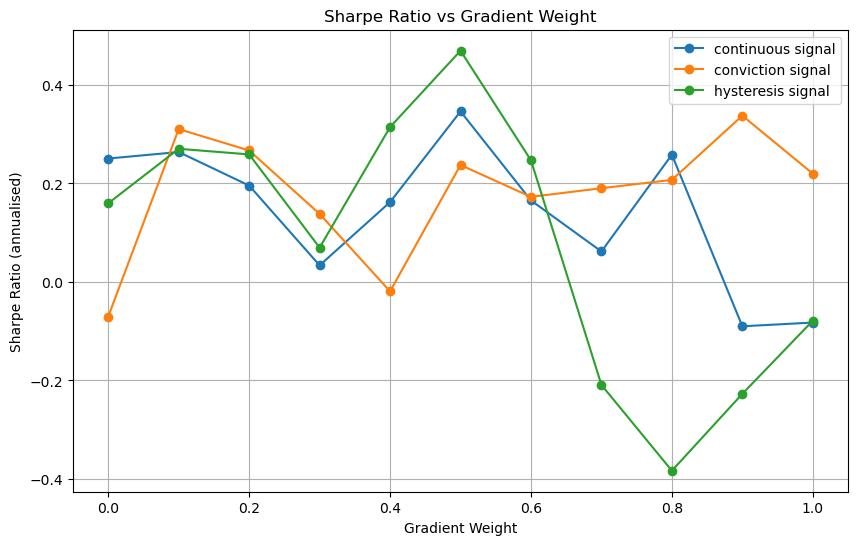

In [22]:
#/Plotting the results 

sharpe_results_continuous = {}
for grad_weight, portfolio_value in results_continuous.items():
    returns = np.diff(portfolio_value) / portfolio_value[:-1]
    if returns.std() > 0:
        sharpe_continuous = (returns.mean() / returns.std()) * np.sqrt(252)  # annualised for 14 years 
    else:
        sharpe_continuous = np.nan
    sharpe_results_continuous[grad_weight] = sharpe_continuous

sharpe_results_conviction = {}
for grad_weight, portfolio_value in results_conviction.items():
    returns = np.diff(portfolio_value) / portfolio_value[:-1]
    if returns.std() > 0:
        sharpe_conviction = (returns.mean() / returns.std()) * np.sqrt(252)  # annualised for 14 years 
    else:
        sharpe_conviction = np.nan
    sharpe_results_conviction[grad_weight] = sharpe_conviction

sharpe_results_hysteresis = {}
for grad_weight, portfolio_value in results_hysteresis.items():
    returns = np.diff(portfolio_value) / portfolio_value[:-1]
    if returns.std() > 0:
        sharpe_hysteresis = (returns.mean() / returns.std()) * np.sqrt(252)  # annualised for 14 years 
    else:
        sharpe_hysteresis = np.nan
    sharpe_results_hysteresis[grad_weight] = sharpe_hysteresis

plt.figure(figsize=(10, 6))
plt.plot(list(sharpe_results_continuous.keys()), list(sharpe_results_continuous.values()), marker='o', label = "continuous signal")
plt.plot(list(sharpe_results_conviction.keys()), list(sharpe_results_conviction.values()), marker='o', label = "conviction signal")
plt.plot(list(sharpe_results_hysteresis.keys()), list(sharpe_results_hysteresis.values()), marker='o', label = "hysteresis signal")
plt.title('Sharpe Ratio vs Gradient Weight')
plt.xlabel('Gradient Weight')
plt.ylabel('Sharpe Ratio (annualised)')
plt.grid()
plt.legend()
plt.show()

Plotting the sensitivity around the optimum alpha = 0.5, to find the 

In [25]:
weights = list(sharpe_results_continuous.keys())
sharpes = list(sharpe_results_continuous.values())

# Fit a parabola around the optimum to measure curvature
coeffs = np.polyfit(weights, sharpes, deg=2)
curvature = coeffs[0]  # negative = concave, well-identified peak

print(f"Curvature: {curvature:.4f}")
print(f"Peak sensitivity: {'Well-identified' if abs(curvature) > 0.5 else 'Flat — interpret with caution'}")

Curvature: -0.4517
Peak sensitivity: Flat — interpret with caution


In [26]:
weights = list(sharpe_results_hysteresis.keys())
sharpes = list(sharpe_results_hysteresis.values())

# Fit a parabola around the optimum to measure curvature
coeffs = np.polyfit(weights, sharpes, deg=2)
curvature = coeffs[0]  # negative = concave, well-identified peak

print(f"Curvature: {curvature:.4f}")
print(f"Peak sensitivity: {'Well-identified' if abs(curvature) > 0.5 else 'Flat — interpret with caution'}")

Curvature: -0.8525
Peak sensitivity: Well-identified


In [27]:
weights = list(sharpe_results_conviction.keys())
sharpes = list(sharpe_results_conviction.values())

# Fit a parabola around the optimum to measure curvature
coeffs = np.polyfit(weights, sharpes, deg=2)
curvature = coeffs[0]  # negative = concave, well-identified peak

print(f"Curvature: {curvature:.4f}")
print(f"Peak sensitivity: {'Well-identified' if abs(curvature) > 0.5 else 'Flat — interpret with caution'}")

Curvature: -0.0082
Peak sensitivity: Flat — interpret with caution


## (2.2) Optimize for temperature parameter $\tau$



In [33]:
h1 = 3
h2 = 1
window_size = 20
N_S = 40
L = 100
_lookback = 10
_use_gradient = True
grad_weight = 0.5
tau_list = [None, 0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0]
S = df_america
_initial_capital = 100
entry_threshold = 0.28
hold_threshold = 0.31


results_conviction = {}
results_hysteresis = {}
results_continuous = {}
for tau in tau_list:
    if tau is not None:         
        print(f"Running for tau={tau}")
    if tau is None: 
        print(f"Running for tau=None, i.e tau mean of centroid distances)")
    portfolio_value_conv, _, _, _  = tr.long_strat_implied(
        initial_capital   = _initial_capital,
        N_S               = N_S,
        S                 = S,
        L                 = L,
        h1                = h1,
        h2                = h2,
        window_size       = window_size,
        start_date        = start_date,
        end_date          = end_date,
        signal_type       = "conviction",
        entry_threshold   = entry_threshold,
        hold_threshold    = hold_threshold,
        gradient_weight       = grad_weight,
        lookback          = _lookback,
        use_gradient      = _use_gradient,
        tau = tau
    )
    portfolio_value_hyst, _, _, _  = tr.long_strat_implied(
        initial_capital   = _initial_capital,
        N_S               = N_S,
        S                 = S,
        L                 = L,
        h1                = h1,
        h2                = h2,
        window_size       = window_size,
        start_date        = start_date,
        end_date          = end_date,
        signal_type       = "hysteresis",
        entry_threshold   = entry_threshold,
        hold_threshold    = hold_threshold,
        gradient_weight       = grad_weight,
        lookback          = _lookback,
        use_gradient      = _use_gradient,
        tau = tau
    )
    portfolio_value_cont, _, _, _  = tr.long_strat_implied(
          initial_capital   = _initial_capital,
        N_S               = N_S,
        S                 = S,
        L                 = L,
        h1                = h1,
        h2                = h2,
        window_size       = window_size,
        start_date        = start_date,
        end_date          = end_date,
        signal_type       = "continuous",
        entry_threshold   = entry_threshold,
        hold_threshold    = hold_threshold,
        gradient_weight       = grad_weight,
        lookback          = _lookback,
        use_gradient      = _use_gradient,
        tau = tau
    )
    
    if tau is None:
        tau = "mean_distance"
    results_conviction[tau] = portfolio_value_conv
    results_hysteresis[tau] = portfolio_value_hyst
    results_continuous[tau] = portfolio_value_cont


Running for tau=None, i.e tau mean of centroid distances)
Running for tau=0.01
Running for tau=0.05
Running for tau=0.1
Running for tau=0.5
Running for tau=1.0
Running for tau=2.0
Running for tau=5.0


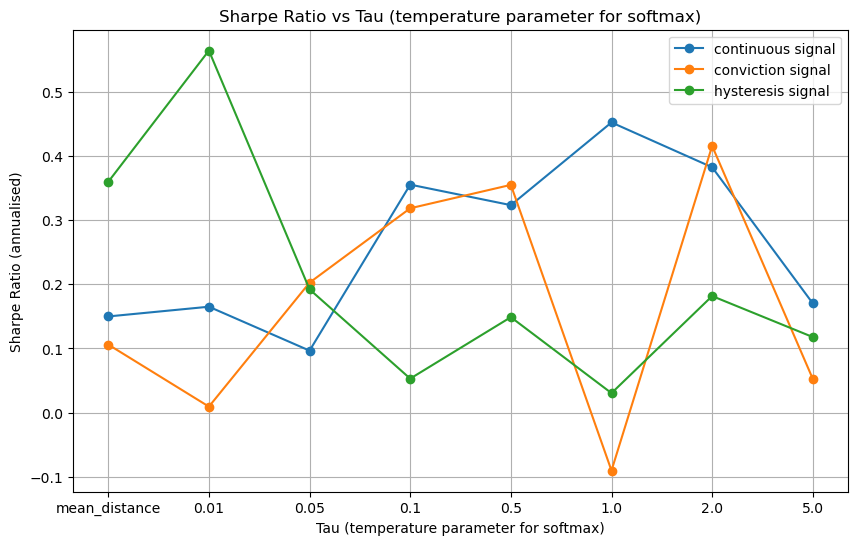

In [34]:
#/Plotting the results 

sharpe_results_continuous = {}
for tau, portfolio_value in results_continuous.items():
    returns = np.diff(portfolio_value) / portfolio_value[:-1]
    if returns.std() > 0:
        sharpe_continuous = (returns.mean() / returns.std()) * np.sqrt(252)  # annualised for 14 years 
    else:
        sharpe_continuous = np.nan
    sharpe_results_continuous[tau] = sharpe_continuous

sharpe_results_conviction = {}
for tau, portfolio_value in results_conviction.items():
    returns = np.diff(portfolio_value) / portfolio_value[:-1]
    if returns.std() > 0:
        sharpe_conviction = (returns.mean() / returns.std()) * np.sqrt(252)  # annualised for 14 years 
    else:
        sharpe_conviction = np.nan
    sharpe_results_conviction[tau] = sharpe_conviction

sharpe_results_hysteresis = {}
for tau, portfolio_value in results_hysteresis.items():
    returns = np.diff(portfolio_value) / portfolio_value[:-1]
    if returns.std() > 0:
        sharpe_hysteresis = (returns.mean() / returns.std()) * np.sqrt(252)  # annualised for 14 years 
    else:
        sharpe_hysteresis = np.nan
    sharpe_results_hysteresis[tau] = sharpe_hysteresis

plt.figure(figsize=(10, 6))
plt.plot(list(sharpe_results_continuous.keys()), list(sharpe_results_continuous.values()), marker='o', label = "continuous signal")
plt.plot(list(sharpe_results_conviction.keys()), list(sharpe_results_conviction.values()), marker='o', label = "conviction signal")
plt.plot(list(sharpe_results_hysteresis.keys()), list(sharpe_results_hysteresis.values()), marker='o', label = "hysteresis signal")
plt.title('Sharpe Ratio vs Tau (temperature parameter for softmax)')
plt.xlabel('Tau (temperature parameter for softmax)')
plt.ylabel('Sharpe Ratio (annualised)')
plt.grid()
plt.legend()
plt.show()

# (3) Tuning Ensemble Method Signal Weighting 

Running Config 1 (Equal) | weights = [0.25, 0.25, 0.25, 0.25]
  → Sharpe Ratio: 0.3827

Running Config 2 | weights = [0.3, 0.1, 0.3, 0.3]
  → Sharpe Ratio: 0.5155

Running Config 3 | weights = [0.2, 0.3, 0.2, 0.3]
  → Sharpe Ratio: 0.3982

Running Config 4 | weights = [0.3, 0.2, 0.3, 0.2]
  → Sharpe Ratio: 0.3934

Running Config 5 | weights = [0.1, 0.4, 0.1, 0.4]
  → Sharpe Ratio: 0.4927


=== Sharpe Ratio Comparison ===
          Config                  Weights  Sharpe Ratio
        Config 2     [0.3, 0.1, 0.3, 0.3]        0.5155
        Config 5     [0.1, 0.4, 0.1, 0.4]        0.4927
        Config 3     [0.2, 0.3, 0.2, 0.3]        0.3982
        Config 4     [0.3, 0.2, 0.3, 0.2]        0.3934
Config 1 (Equal) [0.25, 0.25, 0.25, 0.25]        0.3827


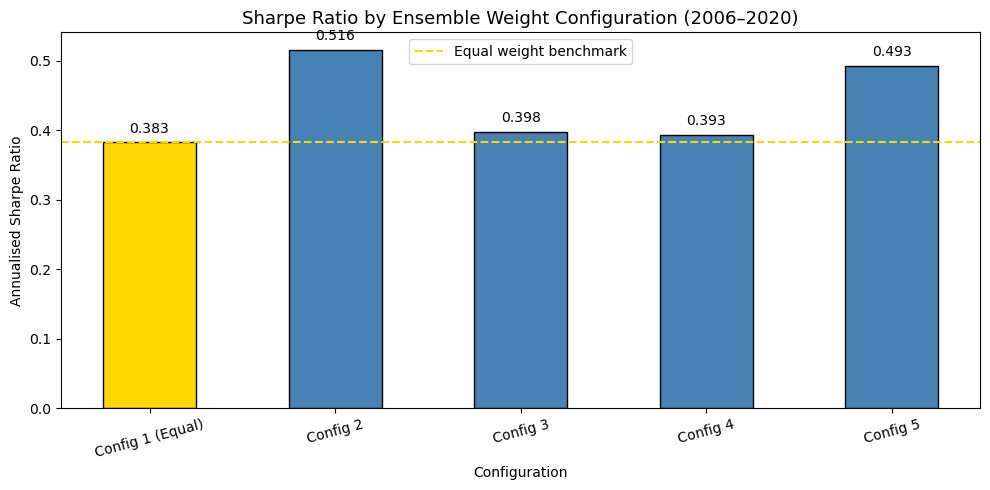

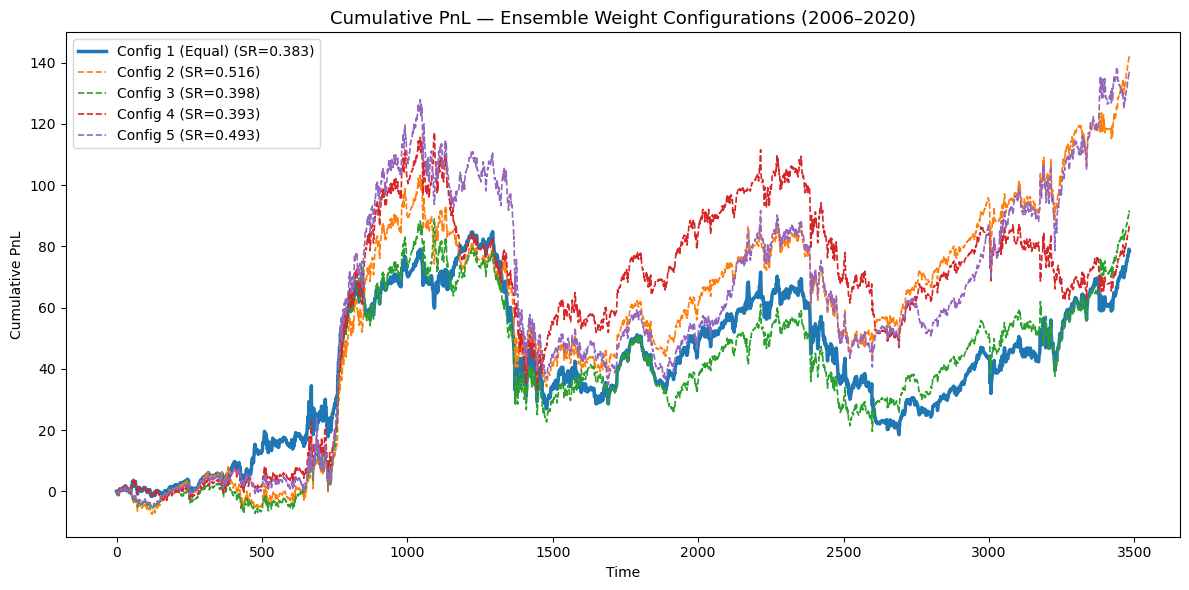

In [7]:

# Parameters
h2 = 1
h1 = 3
window_size = 20
N_S = 40
L = 100
_lookback = 10
grad_weight = 0.5
entry_threshold = 0.28
hold_threshold = 0.31
_use_gradient = False
S = df_america

# Weight configurations [unifortho, hysteresis, continuous, conviction]
_ensemble_weights_list = {
    "Config 1 (Equal)": [0.25, 0.25, 0.25, 0.25],
    "Config 2":         [0.30, 0.10, 0.30, 0.30],
    "Config 3":         [0.20, 0.30, 0.20, 0.30],
    "Config 4":         [0.30, 0.20, 0.30, 0.20],
    "Config 5":         [0.10, 0.40, 0.10, 0.40],
}

# ── Main loop ─────────────────────────────────────────────────────────────────
results = {}

for config_name, weights in _ensemble_weights_list.items():
    print(f"Running {config_name} | weights = {weights}")
    
    portfolio_value, trade_signals, cum_pnl, signal_details = tr.ensemble_strategy(
        initial_capital  = 100,
        N_S              = N_S,
        S                = S,
        L                = L,
        h1               = h1,
        h2               = h2,
        window_size      = window_size,
        K                = 2,
        metric           = "CVaR",
        ensemble_weights = weights,
        lookback         = _lookback,
        use_gradient     = _use_gradient,
        gradient_weight  = grad_weight,
        entry_threshold  = entry_threshold,
        hold_threshold   = hold_threshold,
    )
    
    sharpe = tr.sharpe_ratio(portfolio_value)
    
    results[config_name] = {
        "weights":         weights,
        "portfolio_value": portfolio_value,
        "cum_pnl":         cum_pnl,
        "sharpe":          sharpe,
    }
    
    print(f"  → Sharpe Ratio: {sharpe:.4f}\n")

# ── Summary table ─────────────────────────────────────────────────────────────
summary_df = pd.DataFrame([
    {
        "Config":           name,
        "Weights":          str(res["weights"]),
        "Sharpe Ratio":     round(res["sharpe"], 4),
    }
    for name, res in results.items()
]).sort_values("Sharpe Ratio", ascending=False).reset_index(drop=True)

print("\n=== Sharpe Ratio Comparison ===")
print(summary_df.to_string(index=False))

# ── Plot 1: Sharpe ratio bar chart ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

colors = ["gold" if "Equal" in name else "steelblue" for name in results.keys()]
sharpe_values = [res["sharpe"] for res in results.values()]

bars = ax.bar(results.keys(), sharpe_values, color=colors, edgecolor="black", width=0.5)
ax.axhline(y=results["Config 1 (Equal)"]["sharpe"], color="gold",
           linestyle="--", linewidth=1.5, label="Equal weight benchmark")

for bar, val in zip(bars, sharpe_values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f"{val:.3f}", ha="center", va="bottom", fontsize=10)

ax.set_title("Sharpe Ratio by Ensemble Weight Configuration (2006–2020)", fontsize=13)
ax.set_xlabel("Configuration")
ax.set_ylabel("Annualised Sharpe Ratio")
ax.legend()
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("sharpe_by_config.png", dpi=150)
plt.show()

# ── Plot 2: Cumulative PnL curves ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))

for name, res in results.items():
    lw        = 2.5 if "Equal" in name else 1.2
    linestyle = "-"  if "Equal" in name else "--"
    ax.plot(res["cum_pnl"], label=f"{name} (SR={res['sharpe']:.3f})",
            linewidth=lw, linestyle=linestyle)

ax.set_title("Cumulative PnL — Ensemble Weight Configurations (2006–2020)", fontsize=13)
ax.set_xlabel("Time")
ax.set_ylabel("Cumulative PnL")
ax.legend()
plt.tight_layout()
plt.savefig("cumpnl_by_config.png", dpi=150)
plt.show()